# Random seed comparison

`S3D` was run 10 times with a different random seed. This notebook will present those results when they are finished

See [configfiles/SeedComparison](../../configfiles/SeedComparison/README.md) for more details.

In [1]:
from src.results import fetch_runs
from src.run_types import RESULTS_DIR, RESULTS_OUTPUTS

project_name = 'seed_comparison'
results_dir = RESULTS_DIR / project_name
output_dir = RESULTS_OUTPUTS / project_name

runs = fetch_runs(results_dir / 'filters.py')

print(f'{len(runs)} found')

10 found


## Build a per-seed DataFrame

One row per run, with its seed, test top-k per-instance accuracies and test average loss.

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

from src.visualise2 import (
    LOSS_FMT,
    VALUE_FMT,
    add_iqr_lines,
    plot_bar_chart,
    plot_grouped_bar_chart,
    save_fig,
    set_thesis_style,
)

set_thesis_style()

df = pd.DataFrame(
    [
        {
            "seed": run.admin.seed,
            "Top-1": run.results.test.top_k_per_instance_acc.top1 * 100,
            "Top-5": run.results.test.top_k_per_instance_acc.top5 * 100,
            "Top-10": run.results.test.top_k_per_instance_acc.top10 * 100,
            "Test Loss": run.results.test.average_loss,
        }
        for run in runs
    ]
).sort_values("seed").reset_index(drop=True)

display(df.round(3))

,seed,Top-1,Top-5,Top-10,Test Loss
0,1,75.969,93.411,95.349,1.009
1,2,74.031,92.248,96.124,1.001
2,3,73.643,92.636,94.574,1.066
3,4,72.481,92.248,95.349,1.084
4,5,72.868,93.411,96.124,0.979
5,6,74.031,93.023,95.349,1.038
6,7,74.419,92.248,95.349,1.015
7,8,73.643,91.085,94.186,1.067
8,9,73.643,93.411,96.124,1.002
9,10,72.481,92.636,95.736,1.027


## Summary statistics across seeds

Mean and standard deviation of each metric over the 10 seed runs.

In [3]:
metric_cols = ["Top-1", "Top-5", "Top-10", "Test Loss"]

summary = df[metric_cols].agg(["mean", "std"]).T
summary.columns = ["Mean", "Std"]

display(summary.round(3))

,Mean,Std
Top-1,73.721,1.030
Top-5,92.636,0.731
Top-10,95.426,0.654
Test Loss,1.029,0.034


## Visualise variance across seeds

### Test top-k per-instance accuracy by seed

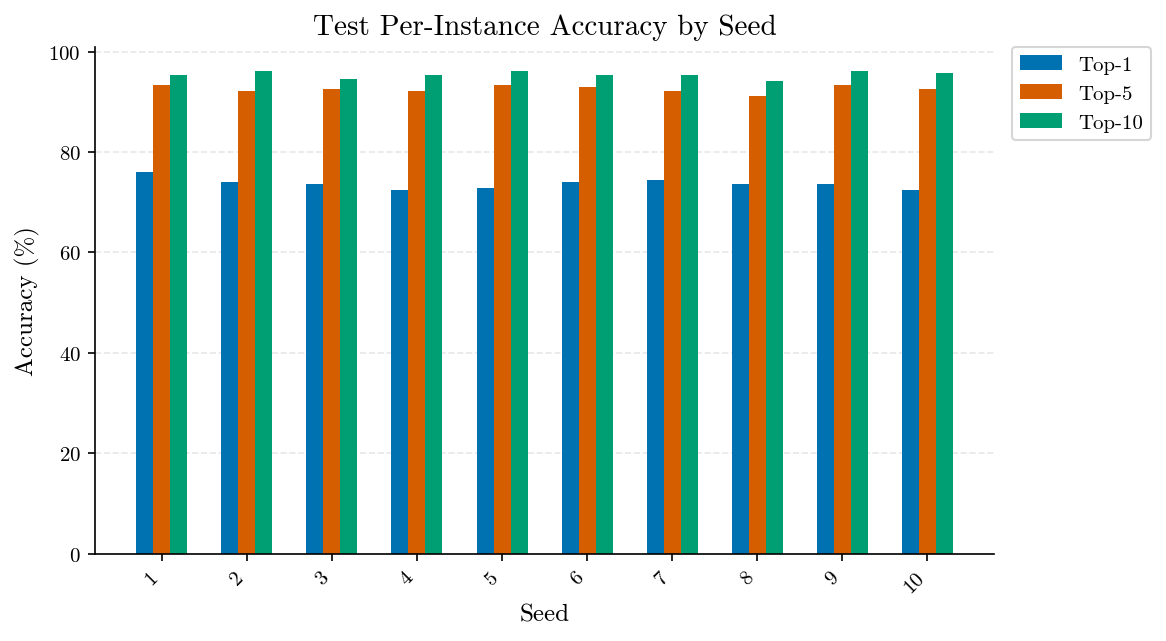

In [4]:
seed_labels = df["seed"].astype(str)

fig, ax = plot_grouped_bar_chart(
    seed_labels,
    {"Top-1": df["Top-1"], "Top-5": df["Top-5"], "Top-10": df["Top-10"]},
    title="Test Per-Instance Accuracy by Seed",
    xlabel="Seed",
    ylabel="Accuracy (%)",
    value_fmt=VALUE_FMT,
    show_values=False
)
save_fig(fig, (output_dir / "top_k_acc_by_seed").with_suffix(".pdf"))
plt.show()

### Test average loss by seed

Dashed line marks the mean loss across seeds.

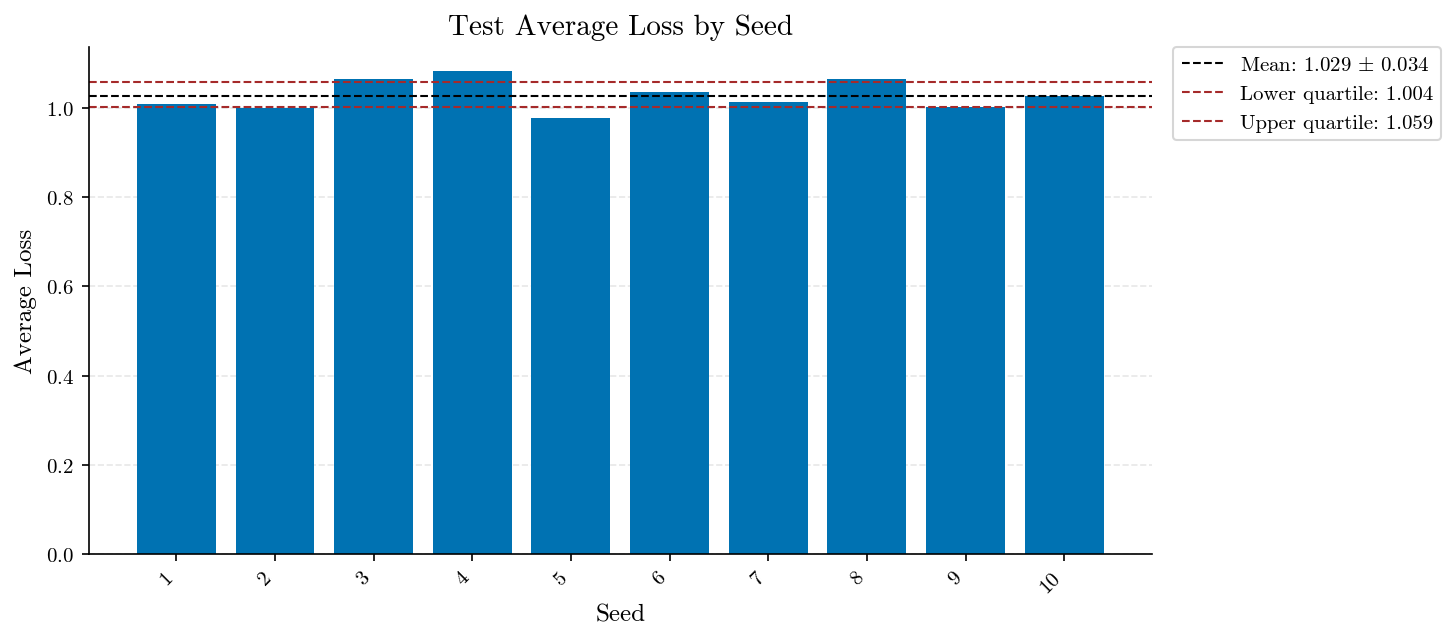

In [5]:
fig, ax = plot_bar_chart(
    seed_labels,
    df["Test Loss"],
    title="Test Average Loss by Seed",
    xlabel="Seed",
    ylabel="Average Loss",
    value_fmt=LOSS_FMT,
    show_values=False
)
add_iqr_lines(ax, df["Test Loss"], value_fmt=LOSS_FMT)
save_fig(fig, (output_dir / "test_loss_by_seed").with_suffix(".pdf"))
plt.show()